In [1]:
# Imports
import sys
import time
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../data")

from data_loading import load_train_test_split

from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Load data
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test:", X_test.shape, y_test.shape)
print("features:", len(feature_cols))
print("classes:", y_train.nunique())
print(y_train.value_counts())

train: (8644, 12) (8644,)
test: (2162, 12) (2162,)
features: 12
classes: 5
Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64


In [3]:
# Helper function
def evaluate_svm(model_name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Weighted F1:", f1)
    print("Macro F1:", macro_f1)
    print("Training Time:", train_time)
    print("Prediction Time:", pred_time)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": f1,
        "Macro F1": macro_f1,
        "Training Time": train_time,
        "Prediction Time": pred_time,
        "Predictions": y_pred,
        "Best Estimator": model
    }

In [4]:
# Hyperparameter tuning: Baseline SVM
C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 1, 5, 10]

baseline_cv_acc = []
baseline_cv_f1 = []

for C in C_values:
    print(f"Training baseline SVM with C = {C}")

    svm = LinearSVC(
        C=C,
        loss="squared_hinge",
        max_iter=10000,
        random_state=42
    )

    acc_scores = cross_val_score(
        svm, X_train, y_train, cv=3, scoring="accuracy"
    )

    f1_scores = cross_val_score(
        svm, X_train, y_train, cv=3, scoring="f1_weighted"
    )

    baseline_cv_acc.append(acc_scores.mean())
    baseline_cv_f1.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

Training baseline SVM with C = 0.001
CV Acc: 0.3730, CV F1: 0.3106
--------------------------------------------------
Training baseline SVM with C = 0.005
CV Acc: 0.3738, CV F1: 0.3109
--------------------------------------------------
Training baseline SVM with C = 0.01
CV Acc: 0.3745, CV F1: 0.3114
--------------------------------------------------
Training baseline SVM with C = 0.05
CV Acc: 0.3745, CV F1: 0.3113
--------------------------------------------------
Training baseline SVM with C = 0.1
CV Acc: 0.3742, CV F1: 0.3111
--------------------------------------------------
Training baseline SVM with C = 1
CV Acc: 0.3738, CV F1: 0.3108
--------------------------------------------------
Training baseline SVM with C = 5
CV Acc: 0.3739, CV F1: 0.3109
--------------------------------------------------
Training baseline SVM with C = 10
CV Acc: 0.3739, CV F1: 0.3109
--------------------------------------------------


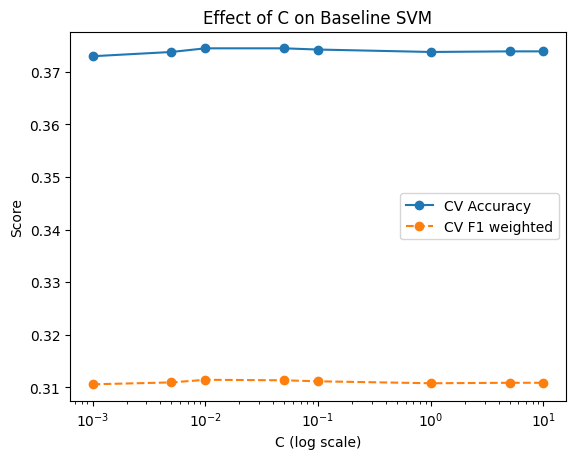

In [5]:
# Plot baseline C tuning
plt.figure()
plt.plot(C_values, baseline_cv_acc, marker="o", label="CV Accuracy")
plt.plot(C_values, baseline_cv_f1, marker="o", linestyle="--", label="CV F1 weighted")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Effect of C on Baseline SVM")
plt.legend()
plt.show()

In [6]:
# Best baseline C
best_baseline_index = baseline_cv_f1.index(max(baseline_cv_f1))
best_baseline_C = C_values[best_baseline_index]

print("Best baseline C:", best_baseline_C)
print("Best baseline CV F1:", baseline_cv_f1[best_baseline_index])

Best baseline C: 0.01
Best baseline CV F1: 0.3114200049927433


In [7]:
# Train final baseline SVM
baseline_svm = LinearSVC(
    C=best_baseline_C,
    loss="squared_hinge",
    max_iter=10000,
    random_state=42
)

baseline_result = evaluate_svm(
    "SVM Baseline",
    baseline_svm,
    X_train,
    X_test,
    y_train,
    y_test
)

SVM Baseline
Accuracy: 0.3700277520814061
Precision: 0.3188796900749592
Recall: 0.3700277520814061
Weighted F1: 0.30689835786726877
Macro F1: 0.1919338348022931
Training Time: 0.07270622253417969
Prediction Time: 0.0006668567657470703

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.60      0.46       764
           1       0.36      0.45      0.40       745
           2       1.00      0.05      0.10       135
           3       0.00      0.00      0.00       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg       0.35      0.22      0.19      2162
weighted avg       0.32      0.37      0.31      2162



In [8]:
# Hyperparameter tuning: Balanced SVM
balanced_cv_acc = []
balanced_cv_f1 = []

for C in C_values:
    print(f"Training balanced SVM with C = {C}")

    svm = LinearSVC(
        C=C,
        loss="squared_hinge",
        class_weight="balanced",
        max_iter=10000,
        random_state=42
    )

    acc_scores = cross_val_score(
        svm, X_train, y_train, cv=3, scoring="accuracy"
    )

    f1_scores = cross_val_score(
        svm, X_train, y_train, cv=3, scoring="f1_weighted"
    )

    balanced_cv_acc.append(acc_scores.mean())
    balanced_cv_f1.append(f1_scores.mean())

    print(f"CV Acc: {acc_scores.mean():.4f}, CV F1: {f1_scores.mean():.4f}")
    print("-" * 50)

Training balanced SVM with C = 0.001
CV Acc: 0.3673, CV F1: 0.3194
--------------------------------------------------
Training balanced SVM with C = 0.005
CV Acc: 0.3682, CV F1: 0.3250
--------------------------------------------------
Training balanced SVM with C = 0.01
CV Acc: 0.3666, CV F1: 0.3245
--------------------------------------------------
Training balanced SVM with C = 0.05
CV Acc: 0.3677, CV F1: 0.3262
--------------------------------------------------
Training balanced SVM with C = 0.1
CV Acc: 0.3672, CV F1: 0.3258
--------------------------------------------------
Training balanced SVM with C = 1
CV Acc: 0.3671, CV F1: 0.3257
--------------------------------------------------
Training balanced SVM with C = 5
CV Acc: 0.3670, CV F1: 0.3256
--------------------------------------------------
Training balanced SVM with C = 10
CV Acc: 0.3670, CV F1: 0.3256
--------------------------------------------------


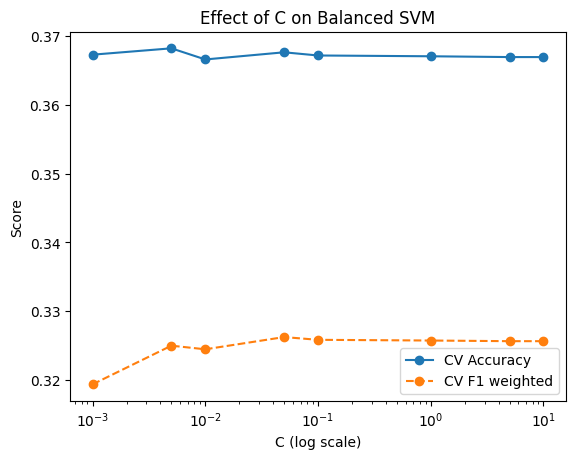

In [9]:
# Plot balanced C tuning
plt.figure()
plt.plot(C_values, balanced_cv_acc, marker="o", label="CV Accuracy")
plt.plot(C_values, balanced_cv_f1, marker="o", linestyle="--", label="CV F1 weighted")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("Effect of C on Balanced SVM")
plt.legend()
plt.show()

In [10]:
# Best balanced C
best_balanced_index = balanced_cv_f1.index(max(balanced_cv_f1))
best_balanced_C = C_values[best_balanced_index]

print("Best balanced C:", best_balanced_C)
print("Best balanced CV F1:", balanced_cv_f1[best_balanced_index])

Best balanced C: 0.05
Best balanced CV F1: 0.32622922140277094


In [11]:
# Train final balanced SVM
balanced_svm = LinearSVC(
    C=best_balanced_C,
    loss="squared_hinge",
    class_weight="balanced",
    max_iter=10000,
    random_state=42
)

balanced_result = evaluate_svm(
    "SVM Balanced",
    balanced_svm,
    X_train,
    X_test,
    y_train,
    y_test
)

SVM Balanced
Accuracy: 0.36725254394079554
Precision: 0.3599724939280279
Recall: 0.36725254394079554
Weighted F1: 0.32041311124796773
Macro F1: 0.20551139069395727
Training Time: 0.07903409004211426
Prediction Time: 0.0007379055023193359

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.57      0.45       764
           1       0.37      0.44      0.40       745
           2       0.70      0.05      0.10       135
           3       0.27      0.05      0.08       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg       0.34      0.22      0.21      2162
weighted avg       0.36      0.37      0.32      2162



In [12]:
# Results Table
svm_results = pd.DataFrame([
    {
        "SVM Model": "Baseline SVM",
        "Class Weight": "None",
        "Best C": best_baseline_C,
        "Accuracy": baseline_result["Accuracy"],
        "Weighted F1": baseline_result["Weighted F1"],
        "Macro F1": baseline_result["Macro F1"],
        "Training Time": baseline_result["Training Time"],
        "Prediction Time": baseline_result["Prediction Time"]
    },
    {
        "SVM Model": "Balanced SVM",
        "Class Weight": "Balanced",
        "Best C": best_balanced_C,
        "Accuracy": balanced_result["Accuracy"],
        "Weighted F1": balanced_result["Weighted F1"],
        "Macro F1": balanced_result["Macro F1"],
        "Training Time": balanced_result["Training Time"],
        "Prediction Time": balanced_result["Prediction Time"]
    }
])

svm_results

,SVM Model,Class Weight,Best C,Accuracy,Weighted F1,Macro F1,Training Time,Prediction Time
0,Baseline SVM,None,0.01,0.370028,0.306898,0.191934,0.072706,0.000667
1,Balanced SVM,Balanced,0.05,0.367253,0.320413,0.205511,0.079034,0.000738


In [13]:
# Pick best SVM based on weighted F1
best_result = (
    baseline_result
    if baseline_result["Weighted F1"] >= balanced_result["Weighted F1"]
    else balanced_result
)

print("Best SVM Model:", best_result["Model"])
print("Best Weighted F1:", best_result["Weighted F1"])

Best SVM Model: SVM Balanced
Best Weighted F1: 0.32041311124796773


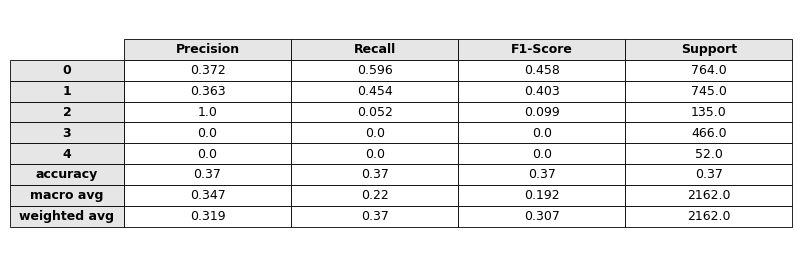

In [14]:
# Baseline SVM classification report table
baseline_report_df = pd.DataFrame(
    classification_report(
        y_test,
        baseline_result["Predictions"],
        output_dict=True,
        zero_division=0
    )
).transpose()

baseline_report_df = baseline_report_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-Score",
    "support": "Support"
}).round(3)

baseline_report_df

# Baseline SVM classification report table image

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.axis("off")

table = ax.table(
    cellText=baseline_report_df.values,
    colLabels=baseline_report_df.columns,
    rowLabels=baseline_report_df.index,
    loc="center",
    cellLoc="center",
    rowLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.15, 1.25)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

    if col == -1:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

plt.savefig("baseline_svm_report.png", bbox_inches="tight", dpi=300, pad_inches=0.05)
plt.show()

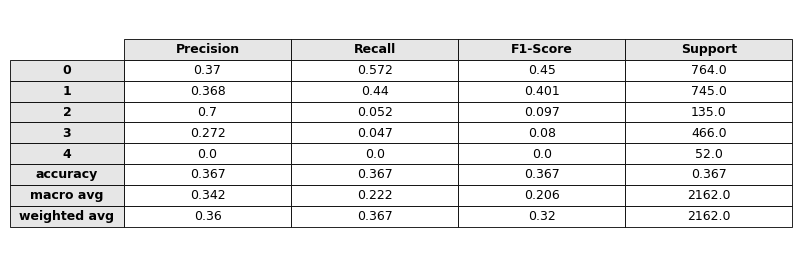

In [15]:
# Balanced SVM classification report table
balanced_report_df = pd.DataFrame(
    classification_report(
        y_test,
        balanced_result["Predictions"],
        output_dict=True,
        zero_division=0
    )
).transpose()

balanced_report_df = balanced_report_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-Score",
    "support": "Support"
}).round(3)

balanced_report_df

# Balanced SVM classification report table image

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.axis("off")

table = ax.table(
    cellText=balanced_report_df.values,
    colLabels=balanced_report_df.columns,
    rowLabels=balanced_report_df.index,
    loc="center",
    cellLoc="center",
    rowLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.15, 1.25)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

    if col == -1:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

plt.savefig("balanced_svm_report.png", bbox_inches="tight", dpi=300, pad_inches=0.05)
plt.show()

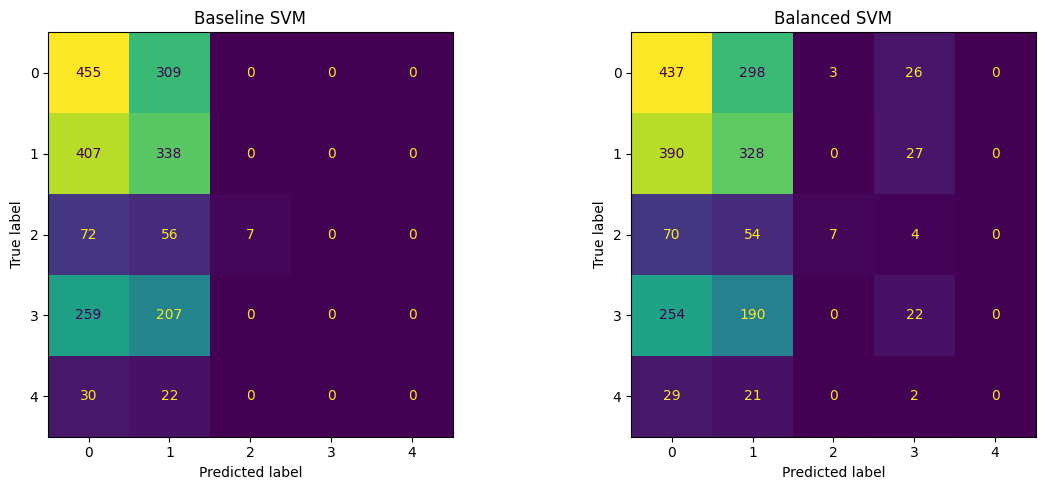

In [16]:
# Confusion Matrices for Baseline and Balanced SVM

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    baseline_result["Predictions"],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Baseline SVM")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    balanced_result["Predictions"],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Balanced SVM")

plt.tight_layout()
plt.show()